In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2



# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

## Introduction

In this tutorial we are going to: 
1. train `IMSContrastiveModel`, 
2. plot training results,
3. compress `imzML` image to latent space in `npz` format using `IMSContrastiveModel`,
4. load **only** latent space

## 1. Training IMSContrastiveModel

In [2]:
# # download prepare data and pretrained_model (~ 600mb)
# !bash scripts/download/download.sh

We need to load imzML image, to do so we use `m2aia` loader and preprocessing tools.

TODO - cite ???

In [3]:
# data loading 
PATH_DATA = Path('data/bladder_data')
PATH_real_data = PATH_DATA / 'bladder_data'  / 'mouse_urinary_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
I = m2.ImzMLReader(
    str(PATH_real_data),
    # We assume TIC normalization
    normalization=m2.m2NormalizationTIC
)

True
!Wed May  6 18:11:52 2026 
3.779! WARNING: No pixel size found, set x and y spacing to 50 microns!
!7.476! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[8.329] [imzML]: data/bladder_data/bladder_data/mouse_urinary_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements
	[normalization]: TIC


To initialize model we do as following steps
- create model instance object (contains path for model folder which stores its parameters)
- create `IMSPyTorchDataset` from loaded m2aia image
- create model by:
  - creating new instance by:
    - setting its dataset `SetIMSDataset`
    - setting its inverse binner `SetInverseBinner`
    - setting its architecture `SetArchitecture`
    - setting its criterion `SetCriterion`
  - loading existing model by `load` method (it takes initialization path)

In [ ]:
# Datasets imports
## Datasets
from IMSAutoEncoderWrapper import IMSPyTorchDataset 
## Binners
from IMSAutoEncoderWrapper.utils.Binners import LinearBinning, NotEmptyInverseBinner, TopPeaksInverseBinner

# creating dataset
# TODO this name is misleading - it is formally dataset
xs_res = I.GetSpacing()[2]
## i round values to max spacing to obtain 'nice' numbers, and i want to consider first and last numbers
xs_min = np.round(I.GetXAxis()[0] - xs_res, int(- np.log10(xs_res)))
xs_max = np.round(I.GetXAxis()[-1] + xs_res, int(- np.log10(xs_res)))
Binner = LinearBinning(
    xs_min=np.round(I.GetXAxis()[0]),
    xs_max=np.ceil(I.GetXAxis()[-1]),
    xs_res=xs_res,
)
# REMARKS - it can be unusable if model is not decoding well enough
# InverseBinner = NotEmptyInverseBinner(Binner)
InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)

dataset= IMSPyTorchDataset(m2aia_img=I, Binner=Binner)

In [5]:
# instantiation model
from IMSAutoEncoderWrapper.model import IMSAutoEncoder

model_path = PATH_DATA / 'bladder_data' / 'model'
model = IMSAutoEncoder(path=model_path, epochs=3)


Model will be loaded on cuda


In [6]:
# model imports
## architectures
from IMSAutoEncoderWrapper.architectures import ContrastiveAutoencoderSkrajny
## criterions
from IMSAutoEncoderWrapper.criterions import ContrastiveCriterion


# Setting model
## Dataset
model.SetIMSDataset(IMSDataset=dataset)

InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)
model.SetInverseBinner(InverseBinner)

## Architecture
### remark: it can ~ 1 min because of dimensions calculations based on IMS
model.SetArchitecture(
    ArchitectureClass=ContrastiveAutoencoderSkrajny,
    latent_dim=128,
    user_hyperparameters=None # it will adjust them automatically
)
## Criterion
### REMARK: we can change it between `fit`
model.SetCriterion(
    CriterionClass=ContrastiveCriterion,
    crit_params={
        'temperature': 2,
        # For faster computation, suggested 'max_peaks_per_spectrum': 2
        'max_peaks_per_spectrum': 1} 

)

[Manager] Binner: LinearBinning initialized.
[Optimization] Setting architecture hyperparameters ...
[Optimization] Estimating peak envelope width ...
[Optimization] Estimated peak envelope width: 23 bins
[Manager] Architecture: ContrastiveAutoencoderSkrajny initialized.
[Manager] Criterion: ContrastiveCriterion initialized.


To train model we run `fit` method
- we can change save path, by default it takes path from `IMSPyTorchDataset` class instance

Our model will save parameters both:
- best: `model_weights.pt` file
- latest: `model_latest.pt` file

In [7]:
model.fit()

[Trainer] Executing REQUIRED_SETUP tasks...
Building noise bank (max 1 peaks per spectrum)...
PeakBank created with 34840 total noise samples.

--- Epoch 1/10 ---
[  5%] 1792/34840 | Loss: 0.2357 | ETA: 7.8 min
[ 10%] 3584/34840 | Loss: 0.1167 | ETA: 5.1 min
[ 15%] 5376/34840 | Loss: 0.0848 | ETA: 3.9 min
[ 21%] 7168/34840 | Loss: 0.0735 | ETA: 3.2 min
[ 26%] 8960/34840 | Loss: 0.0688 | ETA: 2.8 min
[ 31%] 10752/34840 | Loss: 0.0657 | ETA: 2.6 min
[ 36%] 12544/34840 | Loss: 0.0645 | ETA: 2.3 min
[ 41%] 14336/34840 | Loss: 0.0636 | ETA: 2.5 min
[ 46%] 16128/34840 | Loss: 0.0621 | ETA: 2.6 min
[ 51%] 17920/34840 | Loss: 0.0614 | ETA: 2.2 min
[ 57%] 19712/34840 | Loss: 0.0611 | ETA: 1.9 min
[ 62%] 21504/34840 | Loss: 0.0604 | ETA: 1.7 min
[ 67%] 23296/34840 | Loss: 0.0604 | ETA: 1.4 min
[ 72%] 25088/34840 | Loss: 0.0600 | ETA: 1.2 min
[ 77%] 26880/34840 | Loss: 0.0596 | ETA: 0.9 min
[ 82%] 28672/34840 | Loss: 0.0592 | ETA: 0.7 min
[ 87%] 30464/34840 | Loss: 0.0588 | ETA: 0.5 min
[ 93%] 32

In [8]:
# after training we load parameters for which model obtain best results
# Setting model
## Dataset
model.SetIMSDataset(IMSDataset=dataset)
## Loading rest parameters
model.load()

[Warning]: Operating on an trained model. IMSDataset, must have set same binner.
[Manager] Binner already exists LinearBinning initialized.
[Manager] Loading and reconstructing model from data/bladder_data/bladder_data/model
[OK] Component reconstructed: LinearBinning
[OK] Component reconstructed: TopPeaksInverseBinner
[OK] Architecture reconstructed: ContrastiveAutoencoderSkrajny
[FAILED] Criterion ContrastiveCriterion not in registry.
[OK] Weights loaded: model_weights.pt
[OK] History loaded (10 epochs)
--- Model Load Complete ---



## 2. Compress

To compress file we just run compress data. For convenience we also export there our model

In [9]:
path_compress = PATH_DATA / 'compressed_bladder_data'

# compress image
## IMPORTANT: if file with that name exists it will raise error
model.compress_to_file(path_compress / 'mouse_bladder_compressed.npz')
# save model
model.save(path_compress / 'model')

[Model] Encoding image to latent space...
[Model] Done encoding image.
[Model] Compression complete. Saved to: data/bladder_data/compressed_bladder_data/mouse_bladder_compressed.npz
[Manager] Model and configuration saved to data/bladder_data/compressed_bladder_data/model


## 3. Plot training results

To plot training results you can use `history` attribute or predefined methods.

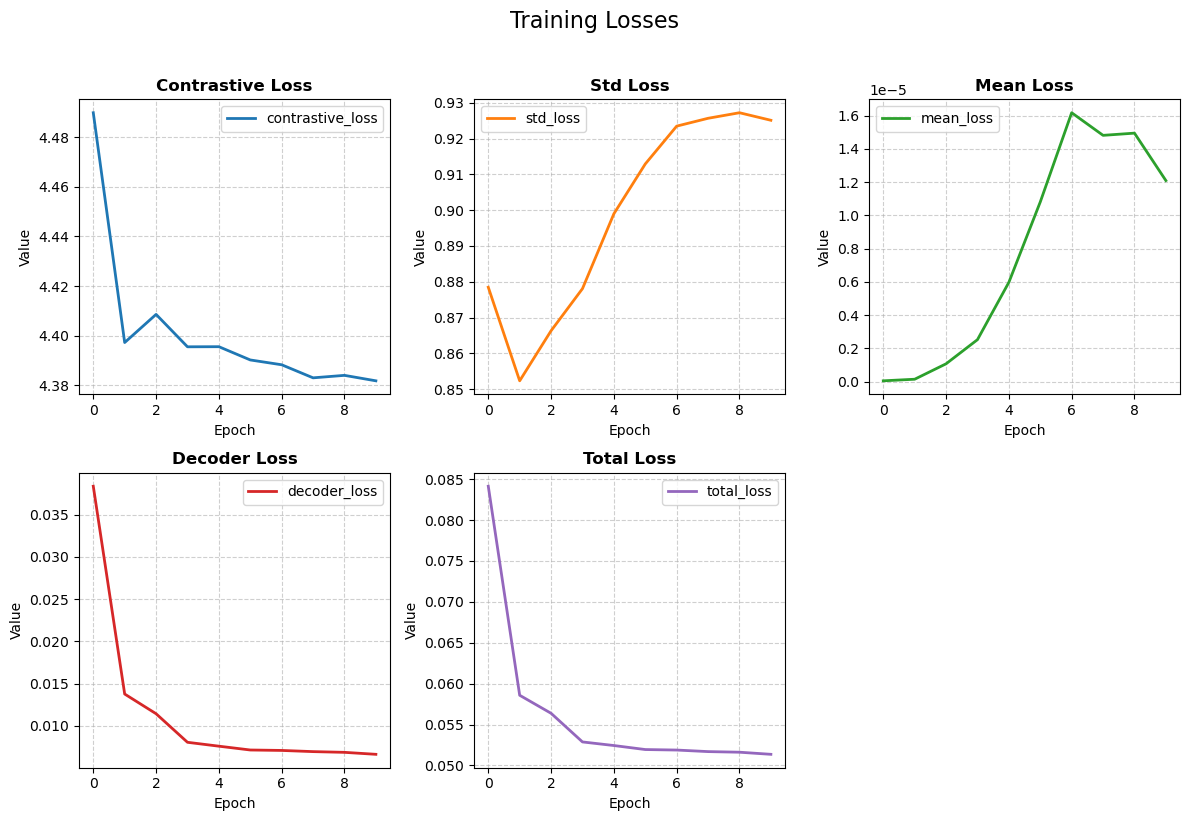

In [13]:
model.plot_epoch_losses()

## 4. Load latent space

You can obtain latent space on two ways:
- encode it, using `transform` method (IMPORTANT: `IMSPyTorchDataset` need to be connected)
- load it from compressed file 

In [17]:
# To obtain latent space in format (spectrum_id X latent) we run
latent_space = model.transform()
latent_space.shape

[Model] Encoding image to latent space...
[Model] Done encoding image.


(34840, 128)

In [15]:
# More convenient way is to use spatial coordinates, to obtain it we use
# case: we do not posses transform data
model.get_latent_grid().shape

[Model] Transforming current image to latent space...
[Model] Encoding image to latent space...
[Model] Done encoding image.


(260, 134, 1, 128)

In [18]:
# If we have already latent space
model.get_latent_grid(
    embeddings=latent_space, 
    coordinates=np.array([I.GetSpectrumPosition(i) for i in range(I.GetNumberOfSpectra())])
).shape

(260, 134, 1, 128)

In [14]:
# If our latent space is in file
model.get_latent_grid(
    compressed_path=path_compress / 'mouse_bladder_compressed.npz'
).shape

[Model] Loading latent space from data/bladder_data/compressed_bladder_data/mouse_bladder_compressed.npz...


(260, 134, 1, 128)

In [ ]:
# or if we do not instantiated model
from IMSAutoEncoderWrapper.utils.LatentSpace import build_latent_grid

data = np.load(path_compress / 'mouse_bladder_compressed.npz', allow_pickle=True)
embeddings = data['embeddings'] # Those are (spectrum_id X latent) format
coordinates = data['coordinates'] # Here are saved coordinates from image
build_latent_grid(embeddings, coordinates).shape

(260, 134, 1, 128)